In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mlt
import seaborn as sns


In [27]:
df = pd.read_csv("waterdemandupdated.csv")

In [28]:
df.head()

,Temperature___C,Humidity_,Soil_moisture,Reference_evapotranspiration,Evapotranspiration,Crop_Coefficient,Crop_Coefficient_stage,Nitrogen_mgkg,Phosphorus_mgkg,Potassium,Solar_Radiation_ghi,Wind_Speed,Days_of_planted,pH,Water_Demand
0,31.2,93.6,567.0,563.000086,236.460036,0.42,Initial Stage,107,38,53,622.0,2.09,1,3.32,236.460036
1,31.2,93.6,567.0,561.176578,235.694163,0.42,Initial Stage,107,38,53,622.0,2.09,1,3.77,235.694163
2,30.5,74.6,307.0,561.267170,235.732211,0.42,Initial Stage,107,38,53,622.0,2.09,3,2.90,235.732211
3,30.4,76.6,308.0,559.447778,234.968067,0.42,Initial Stage,107,38,53,622.0,2.09,3,7.71,234.968067
4,30.4,76.6,308.0,559.447778,234.968067,0.42,Initial Stage,107,38,53,622.0,2.09,3,5.11,234.968067


In [29]:
print(df.columns)


Index(['Temperature___C', 'Humidity_', 'Soil_moisture',
       'Reference_evapotranspiration', 'Evapotranspiration',
       'Crop_Coefficient', 'Crop_Coefficient_stage', 'Nitrogen_mgkg',
       'Phosphorus_mgkg', 'Potassium', 'Solar_Radiation_ghi', 'Wind_Speed',
       'Days_of_planted', 'pH', 'Water_Demand'],
      dtype='object')


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [33]:
def preprocess_dataframe(df):
    """Preprocess DataFrame with specialized handling"""
    # Create a copy to avoid modifying original data
    df_processed = df.copy()
    
    # Encode categorical columns
    categorical_cols = ['Crop_Coefficient_stage']
    for col in categorical_cols:
        if col in df_processed.columns:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    
    return df_processed

def prepare_multilinear_regression(df):
    """Prepare regression with predefined features and targets"""
    # Predefined features
    features = [
        'Temperature___C', 'Humidity_', 'Soil_moisture', 
        'Reference_evapotranspiration', 'Evapotranspiration', 
        'Crop_Coefficient', 'Crop_Coefficient_stage', 
        'Solar_Radiation_ghi', 'Wind_Speed', 
        'Days_of_planted', 'pH'
    ]
    
    # Predefined targets
    targets = ['Nitrogen_mgkg', 'Phosphorus_mgkg', 'Potassium', 'Water_Demand']
    
    # Prepare X and y
    X = df[features]
    y = df[targets]
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features)
        ])
    
    # Train models for each target
    models = {}
    results = {}
    
    for target in targets:
        # Create pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LinearRegression())
        ])
        
        # Fit the model
        pipeline.fit(X_train, y_train[target])
        
        # Predict and evaluate
        y_pred = pipeline.predict(X_test)
        
        # Compute metrics
        mse = mean_squared_error(y_test[target], y_pred)
        r2 = r2_score(y_test[target], y_pred)
        
        models[target] = pipeline
        results[target] = {
            'MSE': mse,
            'R2': r2,
            'Feature_Importances': pipeline.named_steps['regressor'].coef_
        }
    
    return {
        'models': models,
        'results': results,
        'features': features,
        'targets': targets
    }

def predict_with_model(regression_results, new_data):
    """Generate predictions using trained models"""
    predictions = {}
    
    for target, model in regression_results['models'].items():
        predictions[target] = model.predict(new_data[regression_results['features']])
    
    return pd.DataFrame(predictions)

def workflow(df):
    """Complete workflow for regression analysis"""
    # Preprocess DataFrame
    df_processed = preprocess_dataframe(df)
    
    # Perform regression analysis
    regression_results = prepare_multilinear_regression(df_processed)
    
    # Generate predictions
    predictions = predict_with_model(regression_results, df_processed)
    
    return {
        'regression_results': regression_results,
        'predictions': predictions
    }

def print_detailed_results(workflow_results):
    """Print comprehensive results and insights"""
    results = workflow_results['regression_results']['results']
    
    print("\nDetailed Regression Analysis Results:")
    for target, metrics in results.items():
        print(f"\nTarget: {target}")
        print(f"Mean Squared Error: {metrics['MSE']:.4f}")
        print(f"R-squared: {metrics['R2']:.4f}")
        
        print("\nFeature Importances:")
        features = workflow_results['regression_results']['features']
        importances = metrics['Feature_Importances']
        
        for feature, importance in zip(features, importances):
            print(f"{feature}: {importance:.4f}")

In [32]:
print(df.columns.tolist())

['Temperature___C', 'Humidity_', 'Soil_moisture', 'Reference_evapotranspiration', 'Evapotranspiration', 'Crop_Coefficient', 'Crop_Coefficient_stage', 'Nitrogen_mgkg', 'Phosphorus_mgkg', 'Potassium', 'Solar_Radiation_ghi', 'Wind_Speed', 'Days_of_planted', 'pH', 'Water_Demand']


In [34]:
results = workflow(df)

In [35]:
print_detailed_results(results)


Detailed Regression Analysis Results:

Target: Nitrogen_mgkg
Mean Squared Error: 316.6757
R-squared: 0.0781

Feature Importances:
Temperature___C: 0.2262
Humidity_: -0.4338
Soil_moisture: -0.2316
Reference_evapotranspiration: -0.5012
Evapotranspiration: 0.1675
Crop_Coefficient: -0.0279
Crop_Coefficient_stage: -3.5407
Solar_Radiation_ghi: 0.0141
Wind_Speed: 0.3145
Days_of_planted: -1.5152
pH: 0.1321

Target: Phosphorus_mgkg
Mean Squared Error: 381.3161
R-squared: 0.2200

Feature Importances:
Temperature___C: 0.0523
Humidity_: -0.8657
Soil_moisture: -0.1973
Reference_evapotranspiration: 0.6710
Evapotranspiration: 1.5711
Crop_Coefficient: 1.7189
Crop_Coefficient_stage: 4.7762
Solar_Radiation_ghi: 0.1042
Wind_Speed: -0.3338
Days_of_planted: 3.4884
pH: 0.3036

Target: Potassium
Mean Squared Error: 784.8252
R-squared: 0.1033

Feature Importances:
Temperature___C: 0.3183
Humidity_: -0.5437
Soil_moisture: 1.5454
Reference_evapotranspiration: 0.2862
Evapotranspiration: 0.8744
Crop_Coefficient:

In [36]:
predictions = results['predictions']

In [37]:
regression_models = results['regression_results']['models']

In [38]:
# Generate predictions for new or existing data
predictions = results['predictions']
print(predictions)

      Nitrogen_mgkg  Phosphorus_mgkg  Potassium  Water_Demand
0        102.402020        44.434633  63.421543    387.244679
1        102.446831        44.523966  62.824862    384.513880
2        103.414588        46.539575  62.814500    378.947731
3        103.776136        47.396870  56.367820    369.766774
4        103.530737        46.832948  59.791552    373.866974
...             ...              ...        ...           ...
2995      91.379533        73.802460  89.301862    656.623538
2996      91.778433        70.502622  84.455553    321.518846
2997      91.433942        70.603039  92.523063    170.572723
2998      90.942024        71.947008  89.407854   1008.018001
2999      91.218615        75.510923  94.351072    860.734684

[3000 rows x 4 columns]


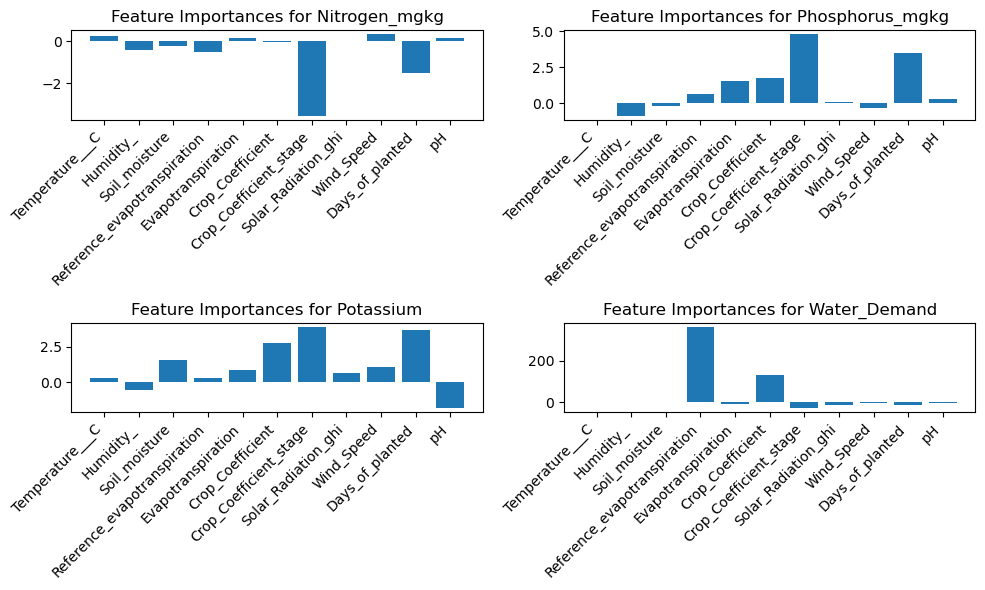

In [39]:
# Visualize Feature Importances
import matplotlib.pyplot as plt

def plot_feature_importances(workflow_results):
    results = workflow_results['regression_results']['results']
    features = workflow_results['regression_results']['features']
    
    plt.figure(figsize=(10, 6))
    for target in results:
        plt.subplot(2, 2, list(results.keys()).index(target) + 1)
        importances = results[target]['Feature_Importances']
        plt.bar(features, importances)
        plt.title(f'Feature Importances for {target}')
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Visualize feature importances
plot_feature_importances(results)

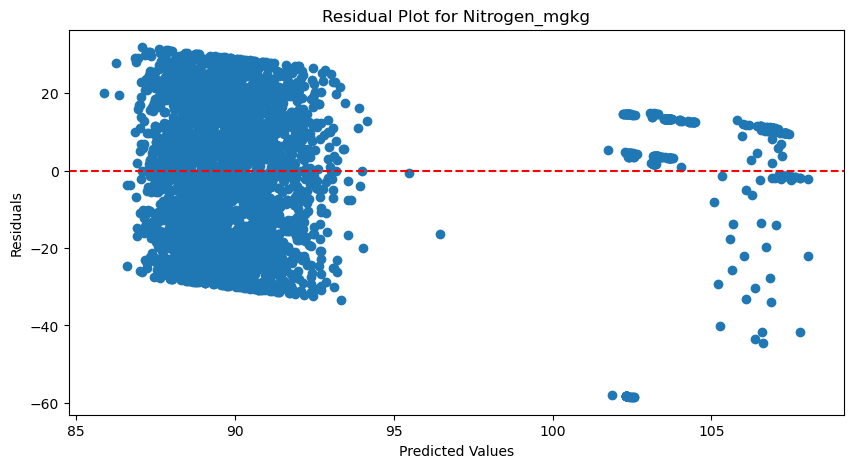

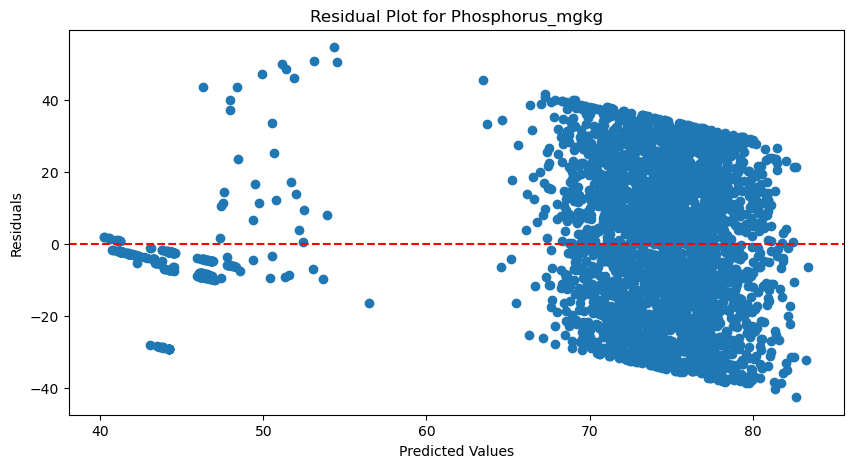

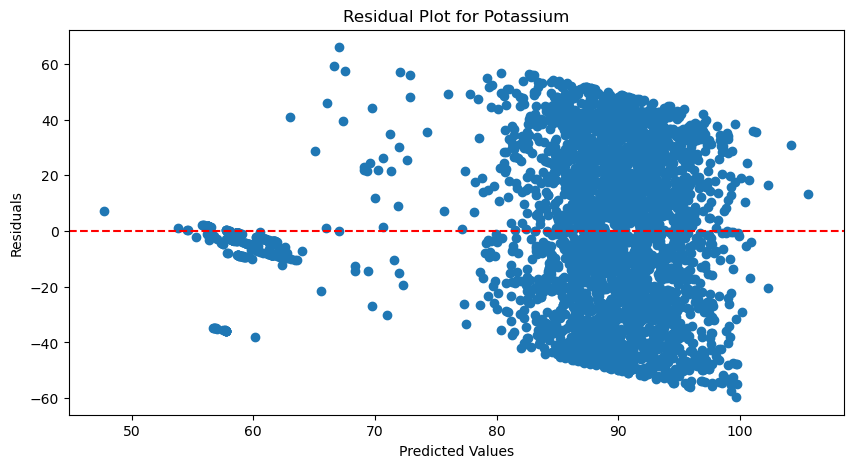

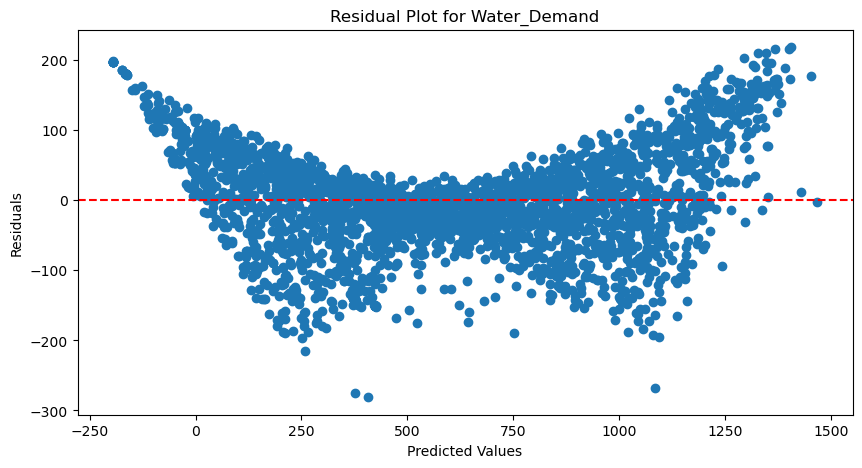

In [40]:
# Residual Analysis
def residual_analysis(workflow_results, df):
    results = workflow_results['regression_results']
    predictions = workflow_results['predictions']
    
    for target in results['targets']:
        actual = df[target]
        predicted = predictions[target]
        residuals = actual - predicted
        
        plt.figure(figsize=(10, 5))
        plt.scatter(predicted, residuals)
        plt.title(f'Residual Plot for {target}')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.axhline(y=0, color='r', linestyle='--')
        plt.show()

# Perform residual analysis
residual_analysis(results, df)

In [41]:
from sklearn.model_selection import cross_val_score

def cross_validation(df):
    # Preprocess the data
    df_processed = preprocess_dataframe(df)
    
    # Prepare features and targets
    features = ['Temperature___C', 'Humidity_', 'Soil_moisture', 
                'Reference_evapotranspiration', 'Evapotranspiration', 
                'Crop_Coefficient', 'Crop_Coefficient_stage', 
                'Solar_Radiation_ghi', 'Wind_Speed', 
                'Days_of_planted', 'pH']
    targets = ['Nitrogen_mgkg', 'Phosphorus_mgkg', 'Potassium', 'Water_Demand']
    
    # Perform cross-validation for each target
    cv_results = {}
    for target in targets:
        X = df_processed[features]
        y = df_processed[target]
        
        # Use pipeline for preprocessing and regression
        pipeline = Pipeline([
            ('preprocessor', StandardScaler()),
            ('regressor', LinearRegression())
        ])
        
        # Perform 5-fold cross-validation
        scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
        
        cv_results[target] = {
            'mean_r2': scores.mean(),
            'std_r2': scores.std()
        }
    
    # Print cross-validation results
    for target, metrics in cv_results.items():
        print(f"{target}:")
        print(f"  Mean R²: {metrics['mean_r2']:.4f}")
        print(f"  Std R²: {metrics['std_r2']:.4f}")
    
    return cv_results

# Perform cross-validation
cross_validation_results = cross_validation(df)

Nitrogen_mgkg:
  Mean R²: -0.0834
  Std R²: 0.1275
Phosphorus_mgkg:
  Mean R²: -0.2361
  Std R²: 0.3697
Potassium:
  Mean R²: -0.1349
  Std R²: 0.2283
Water_Demand:
  Mean R²: 0.9433
  Std R²: 0.0498
